# Research Question 1 — EDA: Player Performance, Club vs. National Team

**Question:** Do players perform differently when representing their national team compared to their club?

**Approach (pure EDA):**
1. Split all StatsBomb men's senior matches into **club** (`is_international = false`) and **national team** (`is_international = true`).
2. Aggregate per-player event counts (shots, xG, passes, pressures, carries, …) within each context.
3. Normalise to **per-90-minute rates**.
4. Explore distributions, top performers, national-team over/under-performers, position profiles, and team-level patterns.

**Data:** `Statsbomb/matches.parquet`, `Statsbomb/events.parquet`, `Statsbomb/lineups.parquet`  
> StatsBomb Open Data — CC BY-NC 4.0

---
## 0. Setup

In [1]:
import os, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

_cwd = Path.cwd()
if (_cwd / "data" / "Statsbomb").is_dir():
    ROOT = _cwd
elif (_cwd.parent / "data" / "Statsbomb").is_dir():
    ROOT = _cwd.parent
else:
    ROOT = _cwd
SB   = os.path.join(ROOT, "data", "Statsbomb")
SB_MATCHES = os.path.join(SB, 'matches.parquet')
SB_EVENTS  = os.path.join(SB, 'events.parquet')
SB_LINEUPS = os.path.join(SB, 'lineups.parquet')

FIGURES_DIR = os.path.join(ROOT, 'results', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

con = duckdb.connect()
def duck(sql): return con.execute(sql).df()

CLR_CLUB     = '#4C72B0'
CLR_NATIONAL = '#DD8452'
PALETTE      = {'Club': CLR_CLUB, 'National': CLR_NATIONAL}

print('Setup complete.')

Setup complete.


---
## 1. Competition Landscape

How many matches exist per competition, and which are club vs. national-team contexts?

In [2]:
competitions = duck(f"""
    SELECT
        competition_name,
        CASE WHEN is_international THEN 'National' ELSE 'Club' END AS context,
        COUNT(DISTINCT match_id)    AS matches,
        COUNT(DISTINCT season_name) AS seasons,
        MIN(match_date) AS earliest,
        MAX(match_date) AS latest
    FROM read_parquet('{SB_MATCHES}')
    WHERE gender = 'male' AND is_youth = false
    GROUP BY competition_name, is_international
    ORDER BY is_international, matches DESC
""")

print(competitions.to_string(index=False))
print("\nTotals by context:")
print(competitions.groupby('context')['matches'].sum().rename('total_matches').to_string())

      competition_name  context  matches  seasons   earliest     latest
               La Liga     Club      868       18 1974-02-17 2021-05-16
               Ligue 1     Club      435        3 2015-08-07 2023-06-03
        Premier League     Club      418        2 2003-08-16 2016-05-17
               Serie A     Club      381        2 1986-11-09 2016-05-15
         1. Bundesliga     Club      340        2 2015-08-14 2024-05-18
   Indian Super league     Club      115        1 2021-11-19 2022-03-20
      Champions League     Club       18       18 1971-06-02 2019-06-01
   Major League Soccer     Club        6        1 2023-08-27 2023-10-22
          Copa del Rey     Club        3        3 1978-04-19 1984-05-05
    UEFA Europa League     Club        3        1 1989-03-15 1989-05-03
      Liga Profesional     Club        2        2 1981-04-10 1997-10-25
 North American League     Club        1        1 1977-08-28 1977-08-28
        FIFA World Cup National      147        8 1958-06-24 202

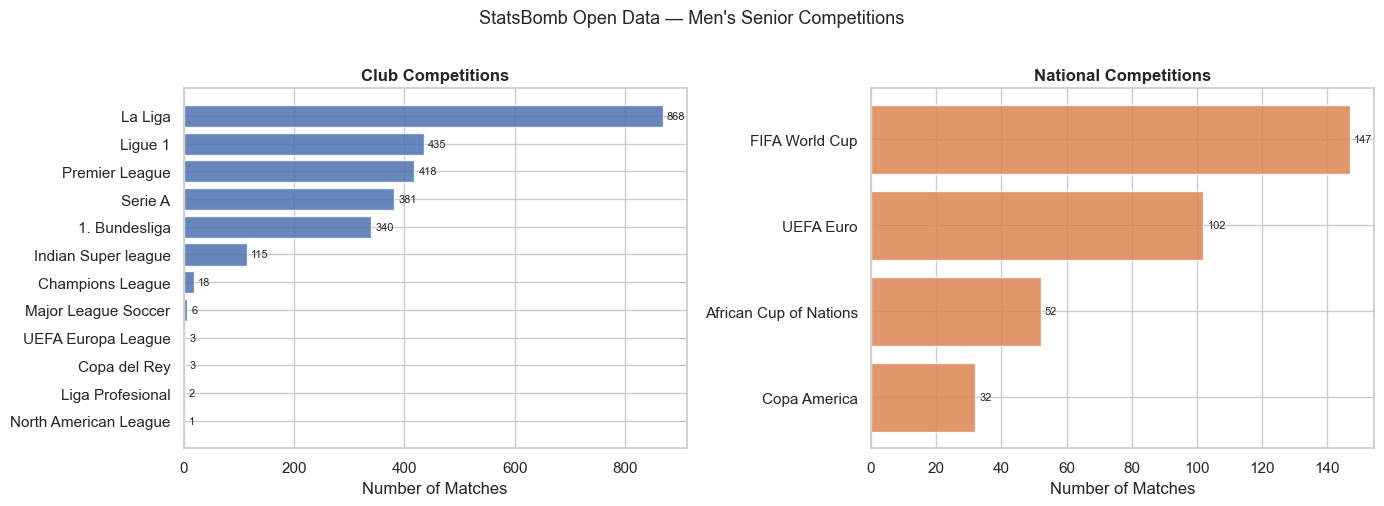

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ctx in zip(axes, ['Club', 'National']):
    sub = competitions[competitions['context'] == ctx].sort_values('matches')
    color = CLR_CLUB if ctx == 'Club' else CLR_NATIONAL
    bars = ax.barh(sub['competition_name'], sub['matches'], color=color, alpha=0.85)
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_xlabel('Number of Matches')
    ax.set_title(f'{ctx} Competitions', fontweight='bold')

fig.suptitle('StatsBomb Open Data — Men\'s Senior Competitions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_01_competition_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Player Minutes per Context

Parse lineup time strings to understand how many minutes each player accumulates
in club vs. national-team football.

In [4]:
def parse_time_to_minutes(t):
    if pd.isna(t) or t == '': return None
    parts = str(t).strip().split(':')
    try:
        if len(parts) == 2:   return int(parts[0]) + int(parts[1]) / 60
        elif len(parts) == 3: return int(parts[0]) * 60 + int(parts[1]) + int(parts[2]) / 60
    except (ValueError, TypeError): return None

lineups_raw = duck(f"""
    SELECT l.match_id, l.player_name, l.team_name, l.position_name,
           l.from_time, l.to_time, m.is_international
    FROM read_parquet('{SB_LINEUPS}') l
    JOIN read_parquet('{SB_MATCHES}') m USING (match_id)
    WHERE l.player_name IS NOT NULL
      AND m.gender = 'male' AND m.is_youth = false
""")

lineups_raw['from_min'] = lineups_raw['from_time'].apply(parse_time_to_minutes).fillna(0)
lineups_raw['to_min']   = lineups_raw['to_time'].apply(parse_time_to_minutes).fillna(90).clip(upper=120)
lineups_raw['minutes_played'] = (lineups_raw['to_min'] - lineups_raw['from_min']).clip(lower=0)
lineups_raw['context'] = lineups_raw['is_international'].map({True: 'National', False: 'Club'})

player_ctx_minutes = (
    lineups_raw
    .groupby(['player_name', 'context'])
    .agg(
        total_minutes=('minutes_played', 'sum'),
        match_count=('match_id', 'nunique'),
        position_name=('position_name',
                       lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else 'Unknown')
    )
    .reset_index()
)

print(f"Total player-context combinations: {len(player_ctx_minutes):,}")
both = (set(player_ctx_minutes[player_ctx_minutes.context=='Club'].player_name)
        & set(player_ctx_minutes[player_ctx_minutes.context=='National'].player_name))
print(f"Players with ANY minutes in BOTH contexts: {len(both):,}")

Total player-context combinations: 9,945
Players with ANY minutes in BOTH contexts: 973


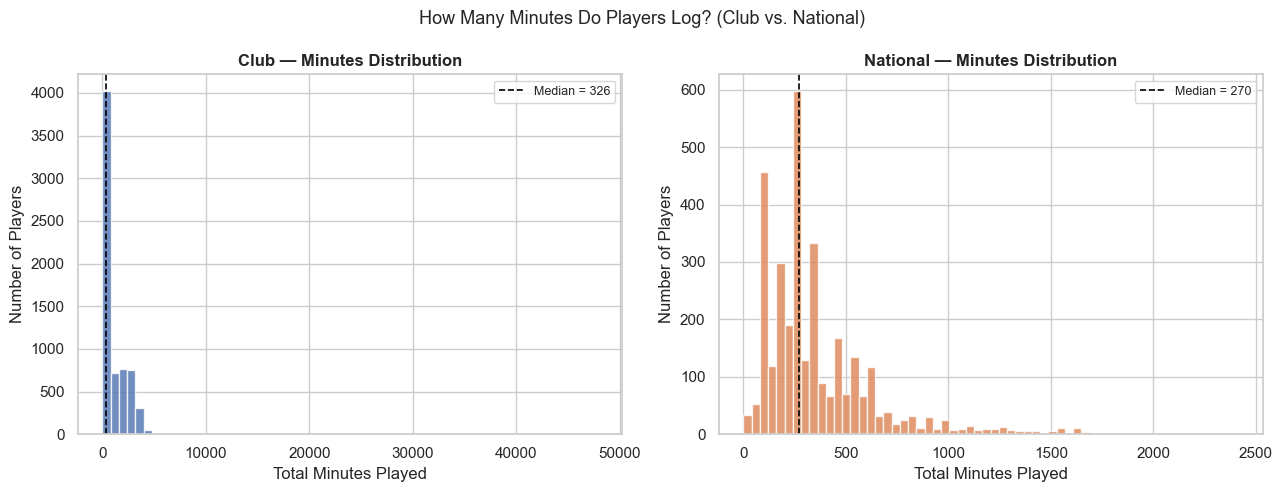

In [5]:
# Distribution of total minutes — club vs national
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, ctx in zip(axes, ['Club', 'National']):
    mins = player_ctx_minutes[player_ctx_minutes.context == ctx]['total_minutes']
    color = CLR_CLUB if ctx == 'Club' else CLR_NATIONAL
    ax.hist(mins, bins=60, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(mins.median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median = {mins.median():.0f}')
    ax.set_xlabel('Total Minutes Played')
    ax.set_ylabel('Number of Players')
    ax.set_title(f'{ctx} — Minutes Distribution', fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('How Many Minutes Do Players Log? (Club vs. National)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_02_minutes_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

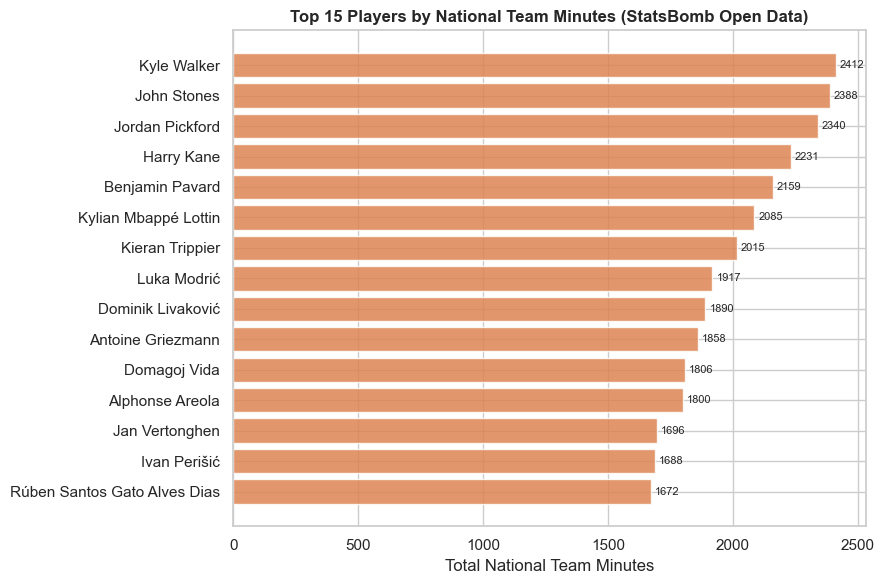

In [6]:
# Top-15 most-used players in national team football
top_nat = (
    player_ctx_minutes[player_ctx_minutes.context == 'National']
    .nlargest(15, 'total_minutes')
    .sort_values('total_minutes')
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_nat['player_name'], top_nat['total_minutes'],
               color=CLR_NATIONAL, alpha=0.85)
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
ax.set_xlabel('Total National Team Minutes')
ax.set_title('Top 15 Players by National Team Minutes (StatsBomb Open Data)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_03_top_national_minutes.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Event Aggregation by Player & Context

DuckDB aggregation on `events.parquet` (755 MB) — joined with match metadata so each
action is labelled Club or National. Never loaded fully into RAM.

In [7]:
player_events_ctx = duck(f"""
    SELECT
        e.player, e.team, e.match_id,
        CASE WHEN m.is_international THEN 'National' ELSE 'Club' END AS context,
        COUNT(*) FILTER (WHERE e.type = 'Shot')                              AS shots,
        SUM(e.shot_statsbomb_xg) FILTER (WHERE e.type = 'Shot')              AS xg,
        COUNT(*) FILTER (WHERE e.type = 'Pass')                              AS passes,
        COUNT(*) FILTER (WHERE e.type = 'Pass' AND e.pass_outcome IS NULL)   AS passes_completed,
        COUNT(*) FILTER (WHERE e.type = 'Pass' AND e.location_x > 80)       AS passes_att_third,
        COUNT(*) FILTER (WHERE e.type = 'Pressure')                         AS pressures,
        COUNT(*) FILTER (WHERE e.type = 'Carry')                            AS carries,
        COUNT(*) FILTER (WHERE e.type = 'Carry' AND e.location_x > 80)      AS carries_att_third,
        COUNT(*) FILTER (WHERE e.type = 'Duel')                             AS duels,
        COUNT(*) FILTER (WHERE e.type = 'Dribble')                          AS dribbles,
        COUNT(*) FILTER (WHERE e.type = 'Interception')                     AS interceptions,
        COUNT(*) FILTER (WHERE e.type = 'Clearance')                        AS clearances,
        COUNT(*) FILTER (WHERE e.type = 'Ball Receipt*')                    AS ball_receipts
    FROM read_parquet('{SB_EVENTS}') e
    JOIN read_parquet('{SB_MATCHES}') m ON e.match_id = m.match_id
    WHERE e.player IS NOT NULL
      AND m.gender = 'male' AND m.is_youth = false
    GROUP BY e.player, e.team, e.match_id, m.is_international
""")

print(f"Player-match rows : {len(player_events_ctx):,}")
print(f"Unique players    : {player_events_ctx['player'].nunique():,}")
player_events_ctx.head(3)

Player-match rows : 82,365
Unique players    : 7,524


,player,team,match_id,context,shots,xg,passes,passes_completed,passes_att_third,pressures,carries,carries_att_third,duels,dribbles,interceptions,clearances,ball_receipts
0,Diafra Sakho,West Ham United,3753984,Club,1,0.101,15,8,3,10,15,5,9,2,0,1,46
1,Jordon Ibe,Liverpool,3753984,Club,0,NaN,7,7,3,3,2,2,0,0,0,0,8
2,Christian Benteke Liolo,Liverpool,3753985,Club,1,0.075,30,18,14,4,18,10,9,1,0,0,57


---
## 4. Per-90 Normalization

Sum events per player-context, join with minutes, derive per-90 rates.
Filter to players with **≥ 270 minutes in each context** (~3 full matches) to avoid noise from cameos.

In [8]:
EVENT_COLS = [
    'shots', 'xg', 'passes', 'passes_completed', 'passes_att_third',
    'pressures', 'carries', 'carries_att_third',
    'duels', 'dribbles', 'interceptions', 'clearances', 'ball_receipts'
]

player_ctx_events = (
    player_events_ctx
    .groupby(['player', 'context'])[EVENT_COLS]
    .sum()
    .reset_index()
)

player_ctx_events = player_ctx_events.merge(
    player_ctx_minutes[['player_name', 'context', 'total_minutes', 'match_count', 'position_name']],
    left_on=['player', 'context'], right_on=['player_name', 'context'],
    how='inner'
).drop(columns='player_name')

for col in EVENT_COLS:
    player_ctx_events[f'{col}_p90'] = (
        player_ctx_events[col] / player_ctx_events['total_minutes'] * 90
    )

player_ctx_events['pass_completion_pct'] = (
    player_ctx_events['passes_completed'] / player_ctx_events['passes'].replace(0, np.nan)
)

MIN_MINUTES = 270
elig = player_ctx_events[player_ctx_events['total_minutes'] >= MIN_MINUTES].copy()

elig_club = set(elig[elig.context == 'Club']['player'])
elig_nat  = set(elig[elig.context == 'National']['player'])
dual_players = elig_club & elig_nat

dual = elig[elig['player'].isin(dual_players)].copy()

print(f"Players with {MIN_MINUTES}+ min in BOTH contexts : {len(dual_players):,}")
print(f"Total rows (2 per player)                       : {len(dual):,}")

Players with 270+ min in BOTH contexts : 441
Total rows (2 per player)                       : 882


In [9]:
# Build a wide table: one row per player, club_ and nat_ prefixed columns + delta_
P90_COLS = [f'{c}_p90' for c in EVENT_COLS] + ['pass_completion_pct']

club_wide = dual[dual.context == 'Club'].set_index('player')
nat_wide  = dual[dual.context == 'National'].set_index('player')

wide = club_wide[P90_COLS + ['total_minutes', 'match_count', 'position_name']].rename(
    columns={c: f'club_{c}' for c in P90_COLS}
).join(
    nat_wide[P90_COLS + ['total_minutes', 'match_count']].rename(
        columns={c: f'nat_{c}' for c in P90_COLS}
    ), rsuffix='_nat'
)
wide.rename(columns={'total_minutes': 'club_minutes', 'match_count': 'club_matches',
                     'total_minutes_nat': 'nat_minutes', 'match_count_nat': 'nat_matches'},
            inplace=True)

for col in P90_COLS:
    wide[f'delta_{col}'] = wide[f'nat_{col}'] - wide[f'club_{col}']

wide.reset_index(inplace=True)
print(f"Wide table: {wide.shape[0]} players × {wide.shape[1]} columns")
wide[['player', 'position_name', 'club_minutes', 'nat_minutes',
      'club_xg_p90', 'nat_xg_p90', 'delta_xg_p90']].head(6)

Wide table: 441 players × 48 columns


,player,position_name,club_minutes,nat_minutes,club_xg_p90,nat_xg_p90,delta_xg_p90
0,Aaron Ramsey,Left Defensive Midfield,2855.700,622.967,0.234,0.204,-0.029
1,Abdou Diallo,Left Back,1521.567,596.133,0.011,0.030,0.019
2,Achraf Hakimi Mouh,Right Back,3811.183,1267.167,0.085,0.143,0.058
3,Adam Hložek,Center Forward,1085.483,276.250,0.250,0.190,-0.059
4,Adama Traoré,Left Defensive Midfield,544.000,324.317,0.046,0.271,0.226
5,Adama Traoré Diarra,Left Wing,549.183,373.767,0.020,0.000,-0.020


---
## 5. Overall Metric Distributions — Violin + Box

How are per-90 metrics distributed across all players in each context?

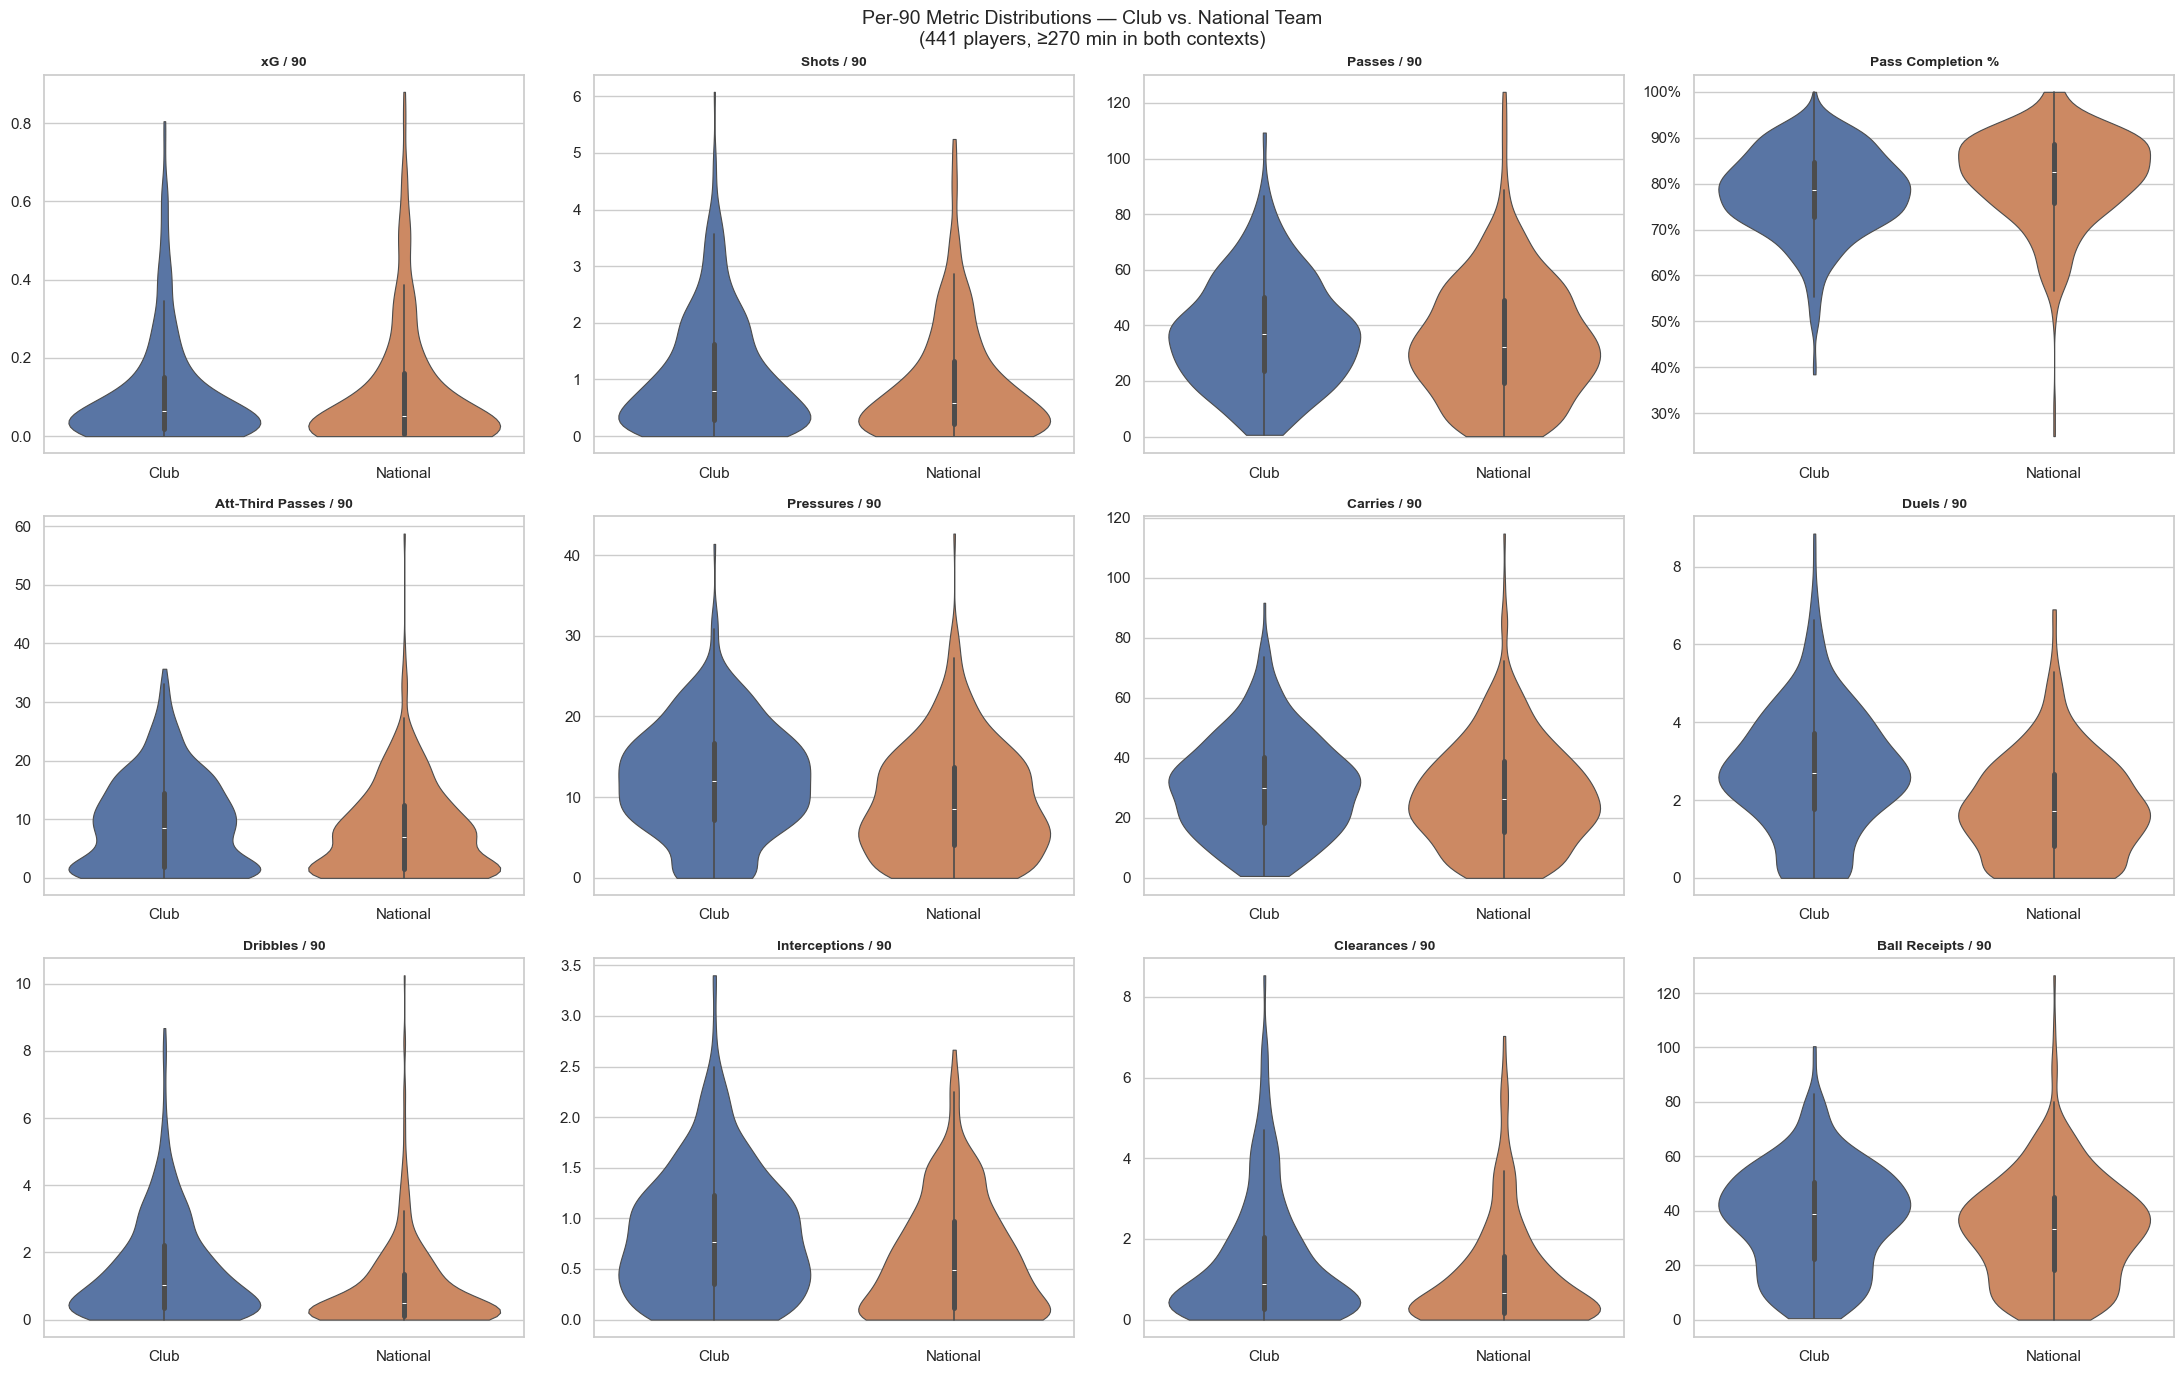

In [10]:
METRICS = {
    'xg_p90'               : 'xG / 90',
    'shots_p90'            : 'Shots / 90',
    'passes_p90'           : 'Passes / 90',
    'pass_completion_pct'  : 'Pass Completion %',
    'passes_att_third_p90' : 'Att-Third Passes / 90',
    'pressures_p90'        : 'Pressures / 90',
    'carries_p90'          : 'Carries / 90',
    'duels_p90'            : 'Duels / 90',
    'dribbles_p90'         : 'Dribbles / 90',
    'interceptions_p90'    : 'Interceptions / 90',
    'clearances_p90'       : 'Clearances / 90',
    'ball_receipts_p90'    : 'Ball Receipts / 90',
}

records = []
for metric in METRICS:
    for _, row in wide.iterrows():
        records.append({'player': row['player'], 'metric': METRICS[metric],
                        'value': row[f'club_{metric}'], 'Context': 'Club'})
        records.append({'player': row['player'], 'metric': METRICS[metric],
                        'value': row[f'nat_{metric}'], 'Context': 'National'})

long_df = pd.DataFrame(records)

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

for i, (metric, label) in enumerate(METRICS.items()):
    ax = axes[i]
    subset = long_df[long_df['metric'] == label]
    sns.violinplot(
        data=subset, x='Context', y='value',
        order=['Club', 'National'],
        palette=PALETTE,
        inner='box', cut=0, linewidth=0.8,
        ax=ax
    )
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    if metric == 'pass_completion_pct':
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

for j in range(len(METRICS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f'Per-90 Metric Distributions — Club vs. National Team\n'
    f'({len(dual_players):,} players, ≥{MIN_MINUTES} min in both contexts)',
    fontsize=14
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_04_violin_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Average per Context — Bar Chart of Metric Means

Simple mean comparison: which metrics tend to be higher or lower at national level?

In [11]:
means = (
    dual
    .groupby('context')[[f'{m}' for m in METRICS] + ['pass_completion_pct']]
    .mean()
    .T
    .rename(columns={'Club': 'Club Mean', 'National': 'National Mean'})
)
means.index = [METRICS.get(i, i) for i in means.index]
means['Delta (Nat − Club)'] = means['National Mean'] - means['Club Mean']
means['Delta %'] = (means['Delta (Nat − Club)'] / means['Club Mean'].replace(0, np.nan) * 100).round(1)

print(means.to_string(float_format='{:.4f}'.format))

context                Club Mean  National Mean  Delta (Nat − Club)  Delta %
xG / 90                   0.1148         0.1189              0.0041   3.6000
Shots / 90                1.0863         0.9285             -0.1578 -14.5000
Passes / 90              37.5267        34.6202             -2.9065  -7.7000
Pass Completion %         0.7799         0.8136              0.0337   4.3000
Att-Third Passes / 90     9.4133         8.1928             -1.2205 -13.0000
Pressures / 90           12.1013         9.3576             -2.7438 -22.7000
Carries / 90             30.4907        27.9462             -2.5444  -8.3000
Duels / 90                2.7169         1.8063             -0.9106 -33.5000
Dribbles / 90             1.4870         0.9497             -0.5373 -36.1000
Interceptions / 90        0.8468         0.6001             -0.2467 -29.1000
Clearances / 90           1.4687         1.1363             -0.3324 -22.6000
Ball Receipts / 90       37.2259        33.0080             -4.2179 -11.3000

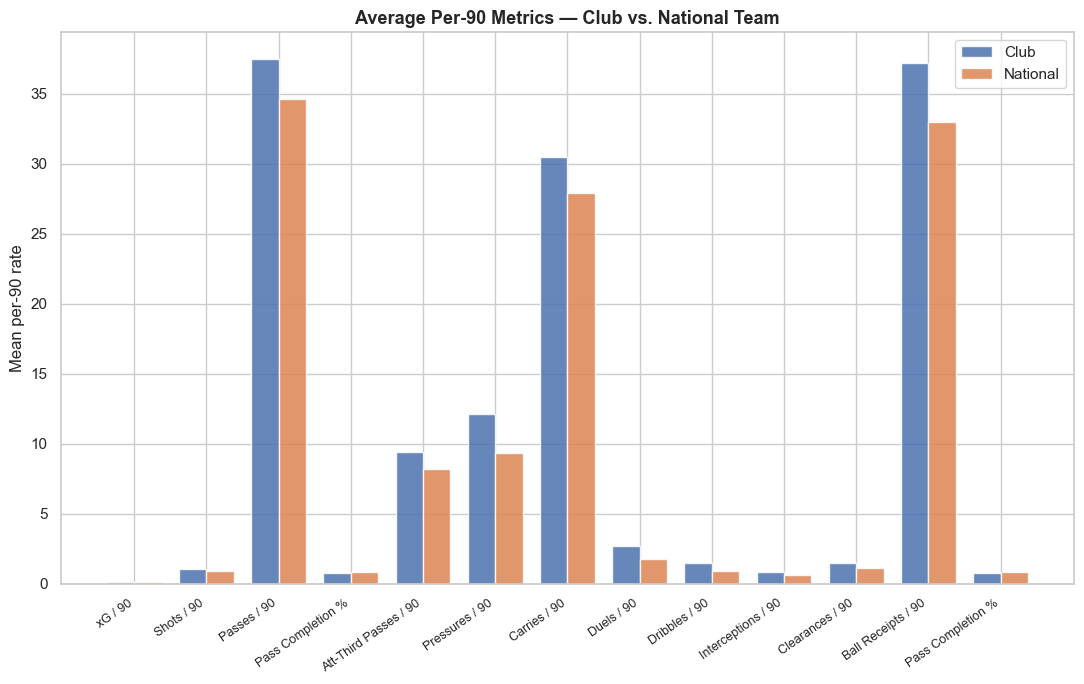

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))

x = np.arange(len(means))
width = 0.38
bars_c = ax.bar(x - width/2, means['Club Mean'],     width, label='Club',     color=CLR_CLUB,     alpha=0.85)
bars_n = ax.bar(x + width/2, means['National Mean'], width, label='National', color=CLR_NATIONAL, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(means.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean per-90 rate')
ax.set_title('Average Per-90 Metrics — Club vs. National Team', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_05_mean_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Delta Distributions — How Much Does Each Player Shift?

For each metric, plot the histogram of (national − club) deltas across all players.
A distribution centred right of zero means players generally do more of that action at national level.

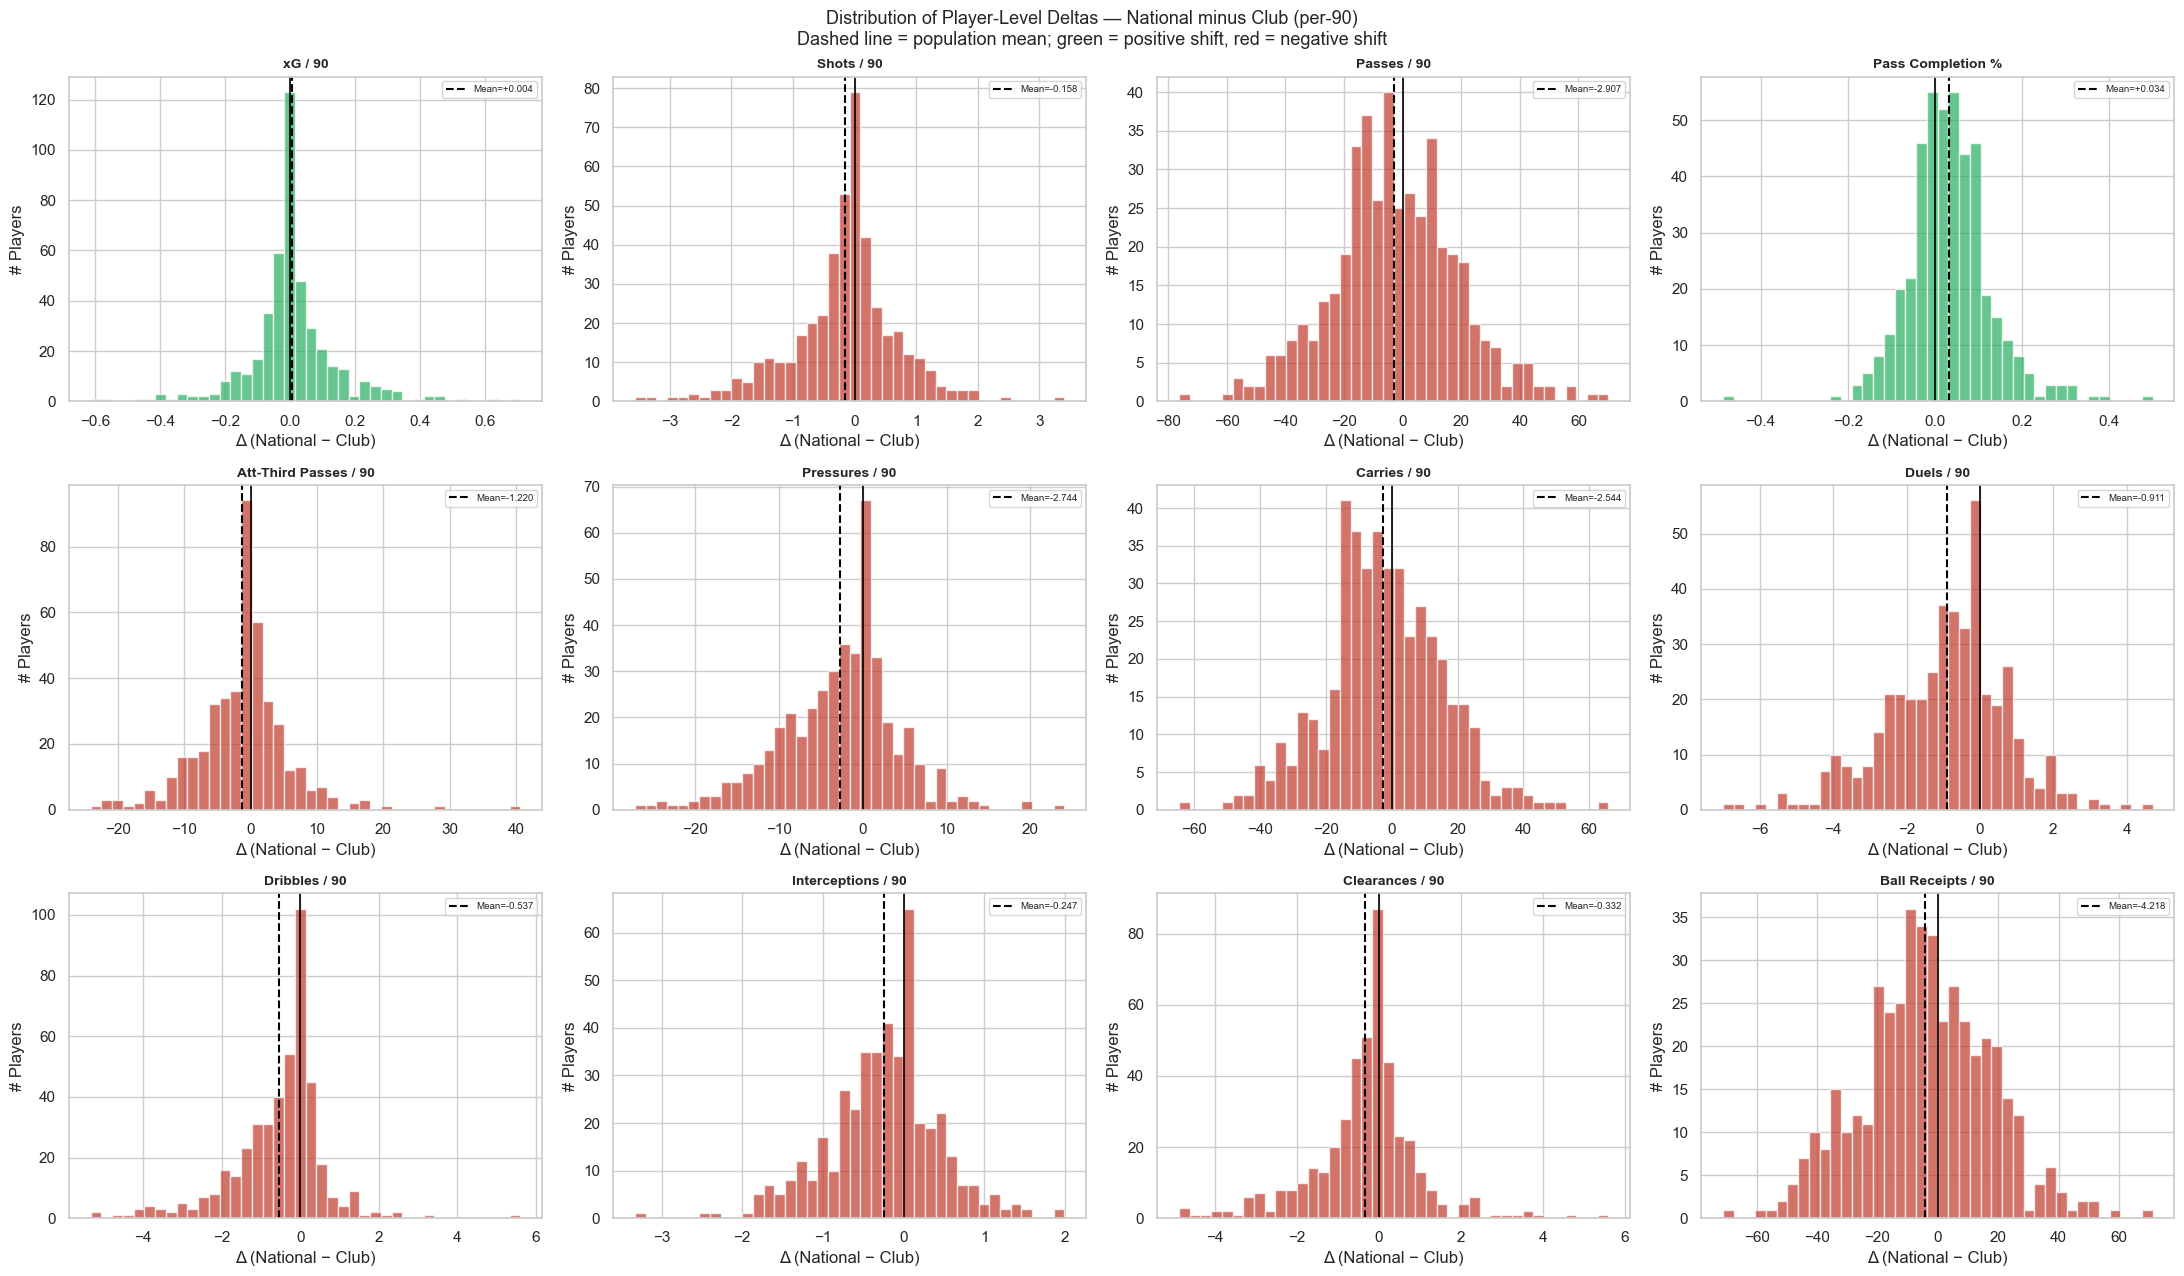

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(22, 13))
axes = axes.flatten()

for i, (metric, label) in enumerate(METRICS.items()):
    ax = axes[i]
    deltas = wide[f'delta_{metric}'].dropna()
    mean_d = deltas.mean()
    color  = '#27ae60' if mean_d >= 0 else '#c0392b'

    ax.hist(deltas, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0,      color='black',  linewidth=1.2, linestyle='-')
    ax.axvline(mean_d, color='black',  linewidth=1.5, linestyle='--',
               label=f'Mean={mean_d:+.3f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Δ (National − Club)')
    ax.set_ylabel('# Players')
    ax.legend(fontsize=7)

for j in range(len(METRICS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Distribution of Player-Level Deltas — National minus Club (per-90)\n'
    'Dashed line = population mean; green = positive shift, red = negative shift',
    fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_06_delta_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Scatter Plots — Club vs. National, Key Metrics

Each point is a player. Points **above** the diagonal perform better for their national team;
points **below** perform better at club level.

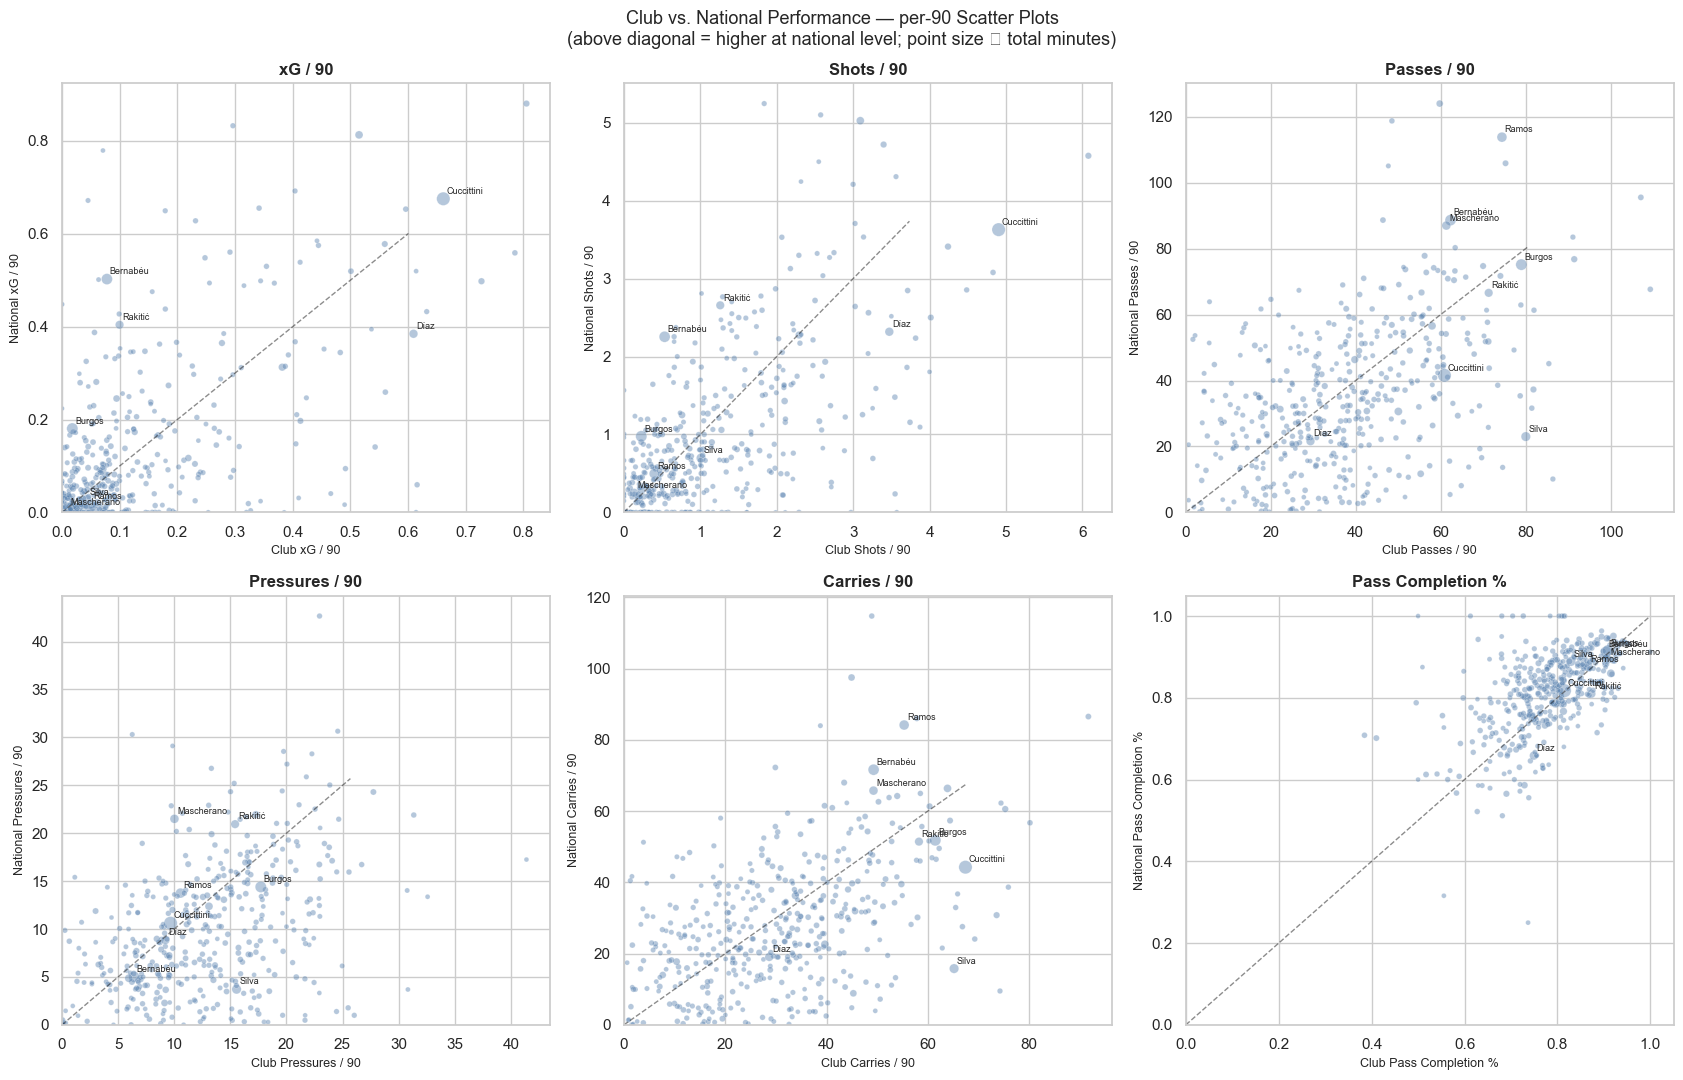

In [14]:
SCATTER_METRICS = [
    ('xg_p90',            'xG / 90'),
    ('shots_p90',         'Shots / 90'),
    ('passes_p90',        'Passes / 90'),
    ('pressures_p90',     'Pressures / 90'),
    ('carries_p90',       'Carries / 90'),
    ('pass_completion_pct', 'Pass Completion %'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()

for ax, (metric, label) in zip(axes, SCATTER_METRICS):
    df_sc = wide[['player', f'club_{metric}', f'nat_{metric}',
                  'club_minutes', 'nat_minutes']].dropna()
    total = df_sc['club_minutes'] + df_sc['nat_minutes']
    sizes = (total - total.min()) / (total.max() - total.min()) * 80 + 12

    ax.scatter(df_sc[f'club_{metric}'], df_sc[f'nat_{metric}'],
               s=sizes, alpha=0.45, color='#5B84B1', edgecolors='white', linewidths=0.3)

    lim_max = max(df_sc[f'club_{metric}'].quantile(0.97),
                  df_sc[f'nat_{metric}'].quantile(0.97)) * 1.05
    lim_min = 0
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            'k--', linewidth=1, alpha=0.5)

    # Annotate top-8 by total minutes
    for _, row in df_sc.nlargest(8, 'club_minutes').iterrows():
        ax.annotate(
            row['player'].split()[-1],
            xy=(row[f'club_{metric}'], row[f'nat_{metric}']),
            fontsize=6.5, ha='left', va='bottom',
            xytext=(2, 2), textcoords='offset points'
        )

    ax.set_xlim(left=lim_min)
    ax.set_ylim(bottom=lim_min)
    ax.set_xlabel(f'Club {label}', fontsize=9)
    ax.set_ylabel(f'National {label}', fontsize=9)
    ax.set_title(label, fontweight='bold')

fig.suptitle(
    'Club vs. National Performance — per-90 Scatter Plots\n'
    '(above diagonal = higher at national level; point size ∝ total minutes)',
    fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_07_scatter_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Top & Bottom Shifters

Which players show the **largest increase or decrease** in key metrics when switching contexts?
Requires at least 270 min in both contexts, so these are genuine dual-context players.

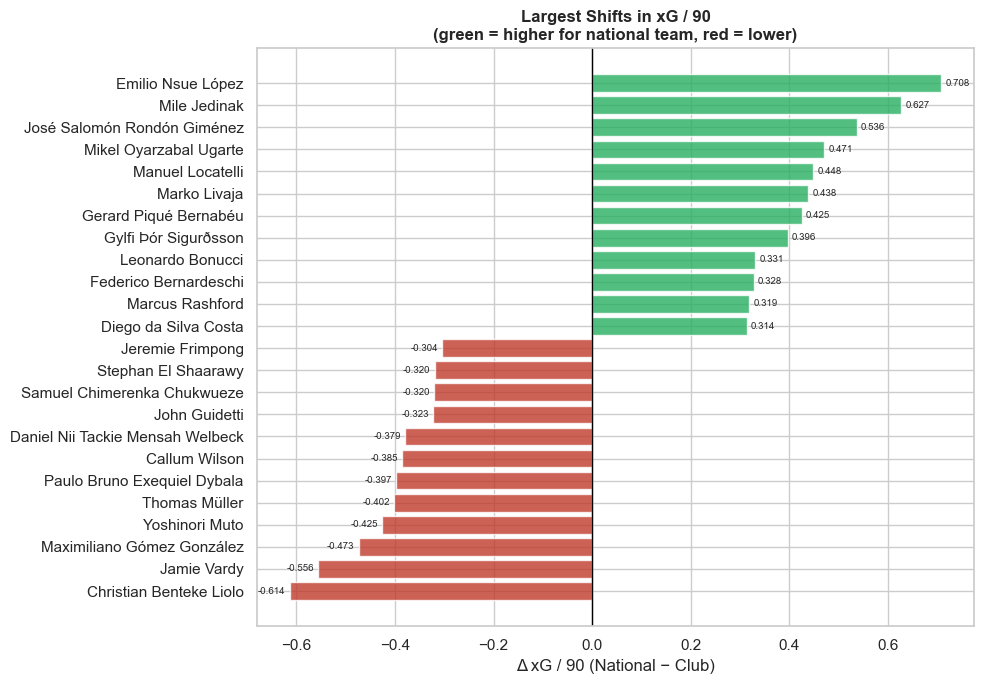

Saved /Users/rabin/Documents/courses/UBC-MDS-Soccer-Capstone-2026/results/figures/eda_shifter_xg_p90.png


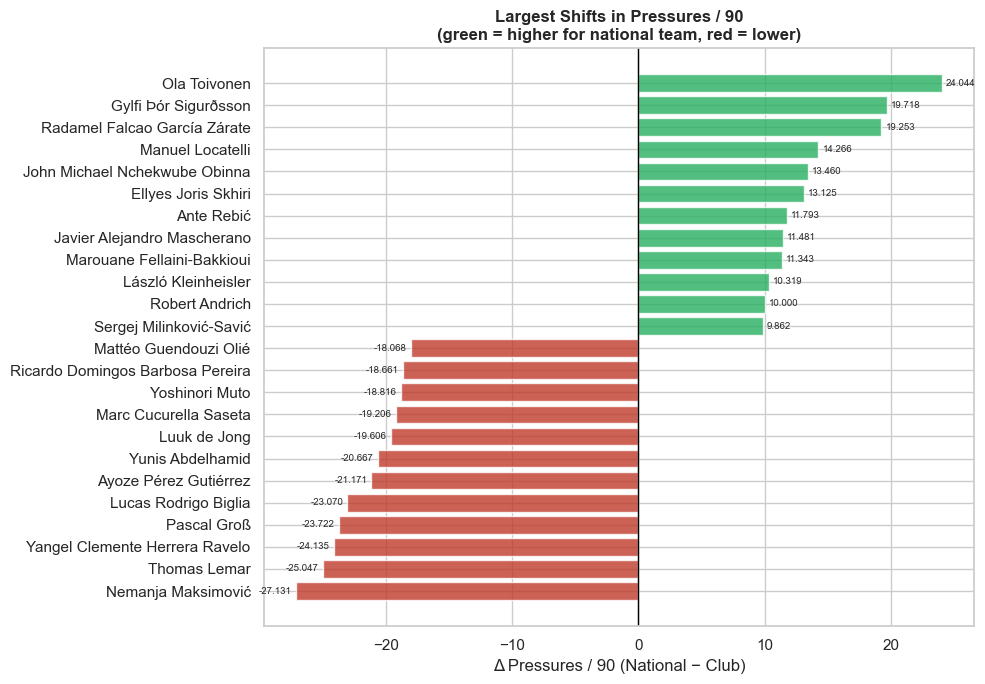

Saved /Users/rabin/Documents/courses/UBC-MDS-Soccer-Capstone-2026/results/figures/eda_shifter_pressures_p90.png


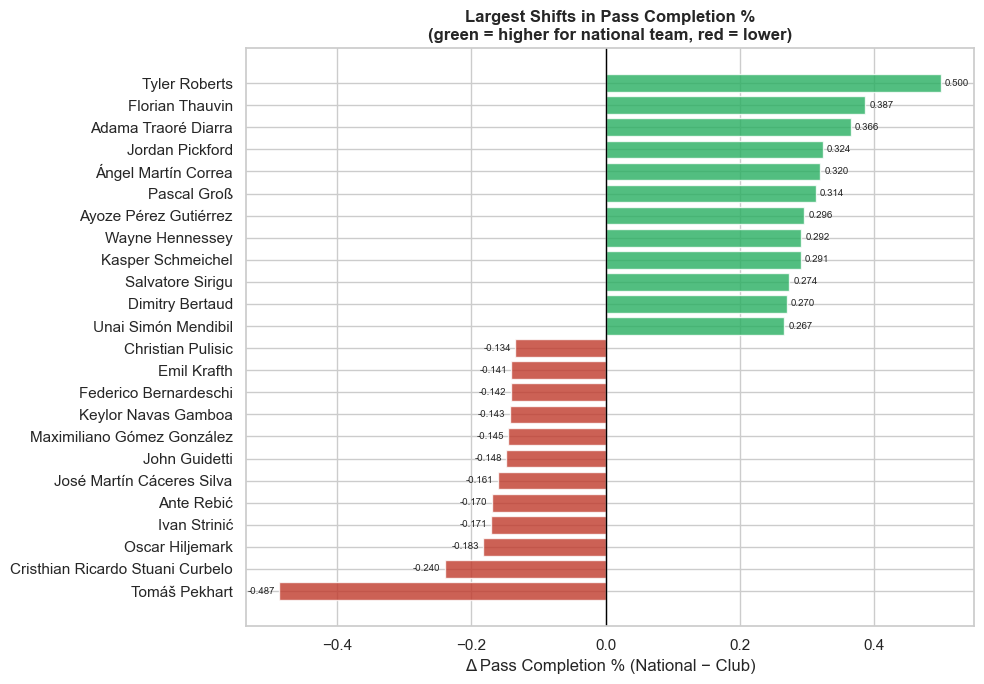

Saved /Users/rabin/Documents/courses/UBC-MDS-Soccer-Capstone-2026/results/figures/eda_shifter_pass_completion_pct.png


In [15]:
def shifter_bars(metric_key, label, n=12):
    col = f'delta_{metric_key}'
    df = wide[['player', 'position_name', f'club_{metric_key}',
               f'nat_{metric_key}', col]].dropna(subset=[col])

    top_pos = df.nlargest(n, col)
    top_neg = df.nsmallest(n, col)
    combined = pd.concat([top_pos, top_neg]).drop_duplicates().sort_values(col)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#27ae60' if v >= 0 else '#c0392b' for v in combined[col]]
    bars = ax.barh(combined['player'], combined[col], color=colors, alpha=0.8)
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=7)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel(f'Δ {label} (National − Club)')
    ax.set_title(
        f'Largest Shifts in {label}\n'
        '(green = higher for national team, red = lower)',
        fontweight='bold'
    )
    plt.tight_layout()
    fname = os.path.join(FIGURES_DIR, f'eda_shifter_{metric_key}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

shifter_bars('xg_p90',           'xG / 90')
shifter_bars('pressures_p90',    'Pressures / 90')
shifter_bars('pass_completion_pct', 'Pass Completion %')

---
## 10. Position Profile — How Does Context Affect Each Position?

Group players into broad positions and compare their average per-90 profiles.

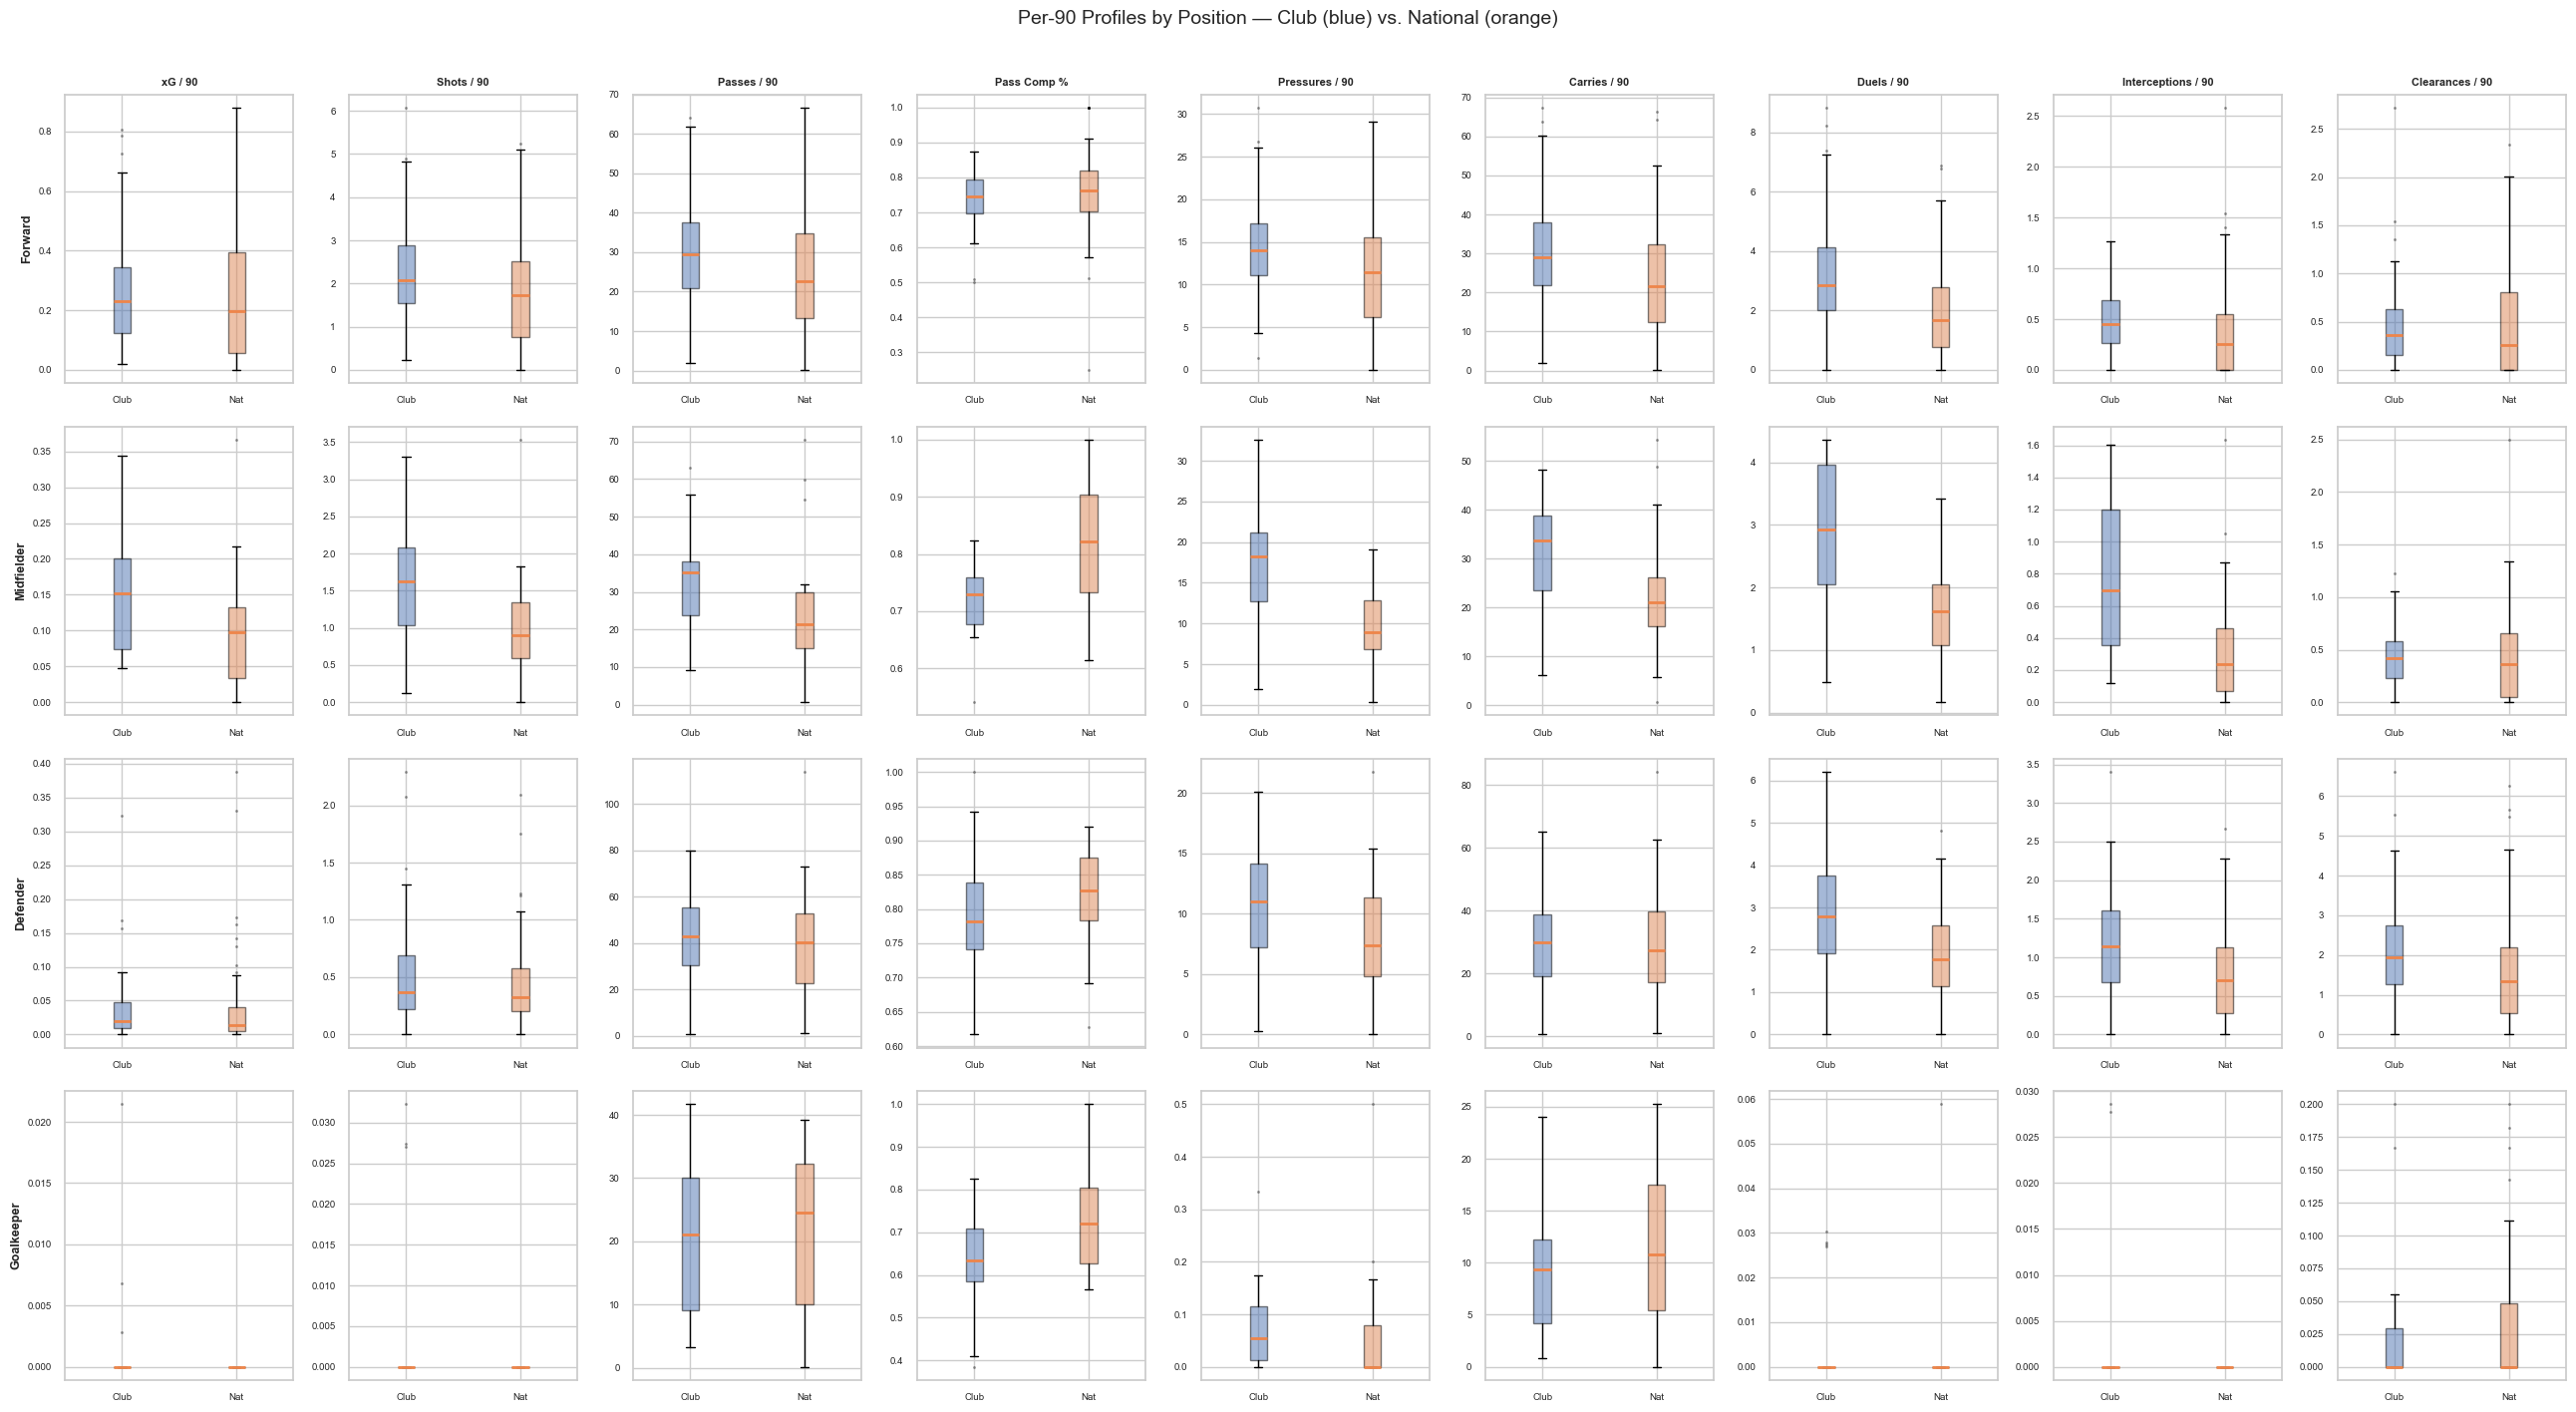

In [16]:
POS_MAP = {
    'Goalkeeper':         'Goalkeeper',
    'Center Back':        'Defender',
    'Left Back':          'Defender',
    'Right Back':         'Defender',
    'Left Wing Back':     'Defender',
    'Right Wing Back':    'Defender',
    'Defensive Midfield': 'Midfielder',
    'Center Midfield':    'Midfielder',
    'Left Midfield':      'Midfielder',
    'Right Midfield':     'Midfielder',
    'Attacking Midfield': 'Midfielder',
    'Left Wing':          'Forward',
    'Right Wing':         'Forward',
    'Center Forward':     'Forward',
    'Secondary Striker':  'Forward',
}

wide['broad_position'] = wide['position_name'].map(POS_MAP).fillna('Unknown')

PROFILE_METRICS = [
    ('xg_p90',            'xG / 90'),
    ('shots_p90',         'Shots / 90'),
    ('passes_p90',        'Passes / 90'),
    ('pass_completion_pct', 'Pass Comp %'),
    ('pressures_p90',     'Pressures / 90'),
    ('carries_p90',       'Carries / 90'),
    ('duels_p90',         'Duels / 90'),
    ('interceptions_p90', 'Interceptions / 90'),
    ('clearances_p90',    'Clearances / 90'),
]

POSITIONS_SHOW = ['Forward', 'Midfielder', 'Defender', 'Goalkeeper']

fig, axes = plt.subplots(len(POSITIONS_SHOW), len(PROFILE_METRICS),
                          figsize=(26, 14), sharey=False)

for row_i, pos in enumerate(POSITIONS_SHOW):
    sub = wide[wide['broad_position'] == pos]
    for col_j, (metric, label) in enumerate(PROFILE_METRICS):
        ax = axes[row_i, col_j]
        c_vals = sub[f'club_{metric}'].dropna()
        n_vals = sub[f'nat_{metric}'].dropna()

        ax.boxplot([c_vals, n_vals], labels=['Club', 'Nat'],
                   patch_artist=True,
                   boxprops=dict(facecolor='none'),
                   medianprops=dict(linewidth=2),
                   flierprops=dict(marker='.', markersize=2, alpha=0.4))

        # Colour the boxes
        for patch, color in zip(ax.patches, [CLR_CLUB, CLR_NATIONAL]):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)

        if row_i == 0:
            ax.set_title(label, fontsize=8, fontweight='bold')
        if col_j == 0:
            ax.set_ylabel(pos, fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)

fig.suptitle(
    'Per-90 Profiles by Position — Club (blue) vs. National (orange)',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_08_position_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Delta Heatmap by Position

Compact view: mean delta (national − club) per metric per position group.
Red = lower at national level; green = higher.

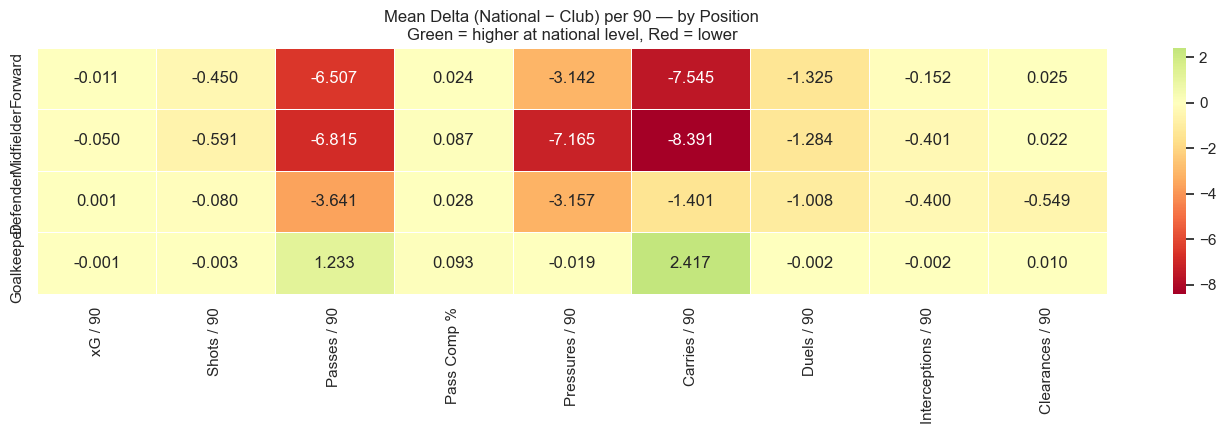

In [17]:
pos_delta = (
    wide[wide['broad_position'].isin(POSITIONS_SHOW)]
    .groupby('broad_position')[[f'delta_{m}' for m, _ in PROFILE_METRICS]]
    .mean()
)
pos_delta.columns = [label for _, label in PROFILE_METRICS]

fig, ax = plt.subplots(figsize=(14, 4.5))
sns.heatmap(
    pos_delta.loc[POSITIONS_SHOW],
    annot=True, fmt='.3f', center=0,
    cmap='RdYlGn', linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title(
    'Mean Delta (National − Club) per 90 — by Position\n'
    'Green = higher at national level, Red = lower',
    fontsize=12
)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_09_position_delta_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 12. National Team Performance by Tournament

Do performance levels differ across tournaments (World Cup vs. Euros vs. AFCON vs. Copa América)?

In [18]:
# Re-aggregate events per player per competition (national team only)
player_tournament = duck(f"""
    SELECT
        e.player,
        m.competition_name AS tournament,
        COUNT(*) FILTER (WHERE e.type = 'Shot')                            AS shots,
        SUM(e.shot_statsbomb_xg) FILTER (WHERE e.type = 'Shot')            AS xg,
        COUNT(*) FILTER (WHERE e.type = 'Pass')                            AS passes,
        COUNT(*) FILTER (WHERE e.type = 'Pass' AND e.pass_outcome IS NULL) AS passes_completed,
        COUNT(*) FILTER (WHERE e.type = 'Pressure')                        AS pressures,
        COUNT(*) FILTER (WHERE e.type = 'Carry')                           AS carries
    FROM read_parquet('{SB_EVENTS}') e
    JOIN read_parquet('{SB_MATCHES}') m ON e.match_id = m.match_id
    WHERE e.player IS NOT NULL
      AND m.gender = 'male' AND m.is_youth = false
      AND m.is_international = true
    GROUP BY e.player, m.competition_name
""")

# Merge with tournament-level minutes
lineup_tournament = duck(f"""
    SELECT l.player_name, m.competition_name AS tournament,
           l.from_time, l.to_time, l.match_id
    FROM read_parquet('{SB_LINEUPS}') l
    JOIN read_parquet('{SB_MATCHES}') m USING (match_id)
    WHERE l.player_name IS NOT NULL
      AND m.gender = 'male' AND m.is_youth = false
      AND m.is_international = true
""")

lineup_tournament['from_min'] = lineup_tournament['from_time'].apply(parse_time_to_minutes).fillna(0)
lineup_tournament['to_min']   = lineup_tournament['to_time'].apply(parse_time_to_minutes).fillna(90).clip(upper=120)
lineup_tournament['minutes_played'] = (lineup_tournament['to_min'] - lineup_tournament['from_min']).clip(lower=0)

mins_tourn = (
    lineup_tournament
    .groupby(['player_name', 'tournament'])
    ['minutes_played'].sum()
    .reset_index()
)

pt = player_tournament.merge(
    mins_tourn, left_on=['player', 'tournament'], right_on=['player_name', 'tournament'], how='inner'
).drop(columns='player_name')

# Per-90 for tournament-level
for col in ['shots','xg','passes','passes_completed','pressures','carries']:
    pt[f'{col}_p90'] = pt[col] / pt['minutes_played'] * 90
pt['pass_completion_pct'] = pt['passes_completed'] / pt['passes'].replace(0, np.nan)

pt_eligible = pt[pt['minutes_played'] >= MIN_MINUTES]
print(pt_eligible.groupby('tournament')[['shots_p90','xg_p90','pressures_p90']].mean().round(3))

                        shots_p90  xg_p90  pressures_p90
tournament                                              
African Cup of Nations      0.622   0.134          8.029
Copa America                0.677   0.124          8.082
FIFA World Cup              0.749   0.129          8.998
UEFA Euro                   0.757   0.120          8.961


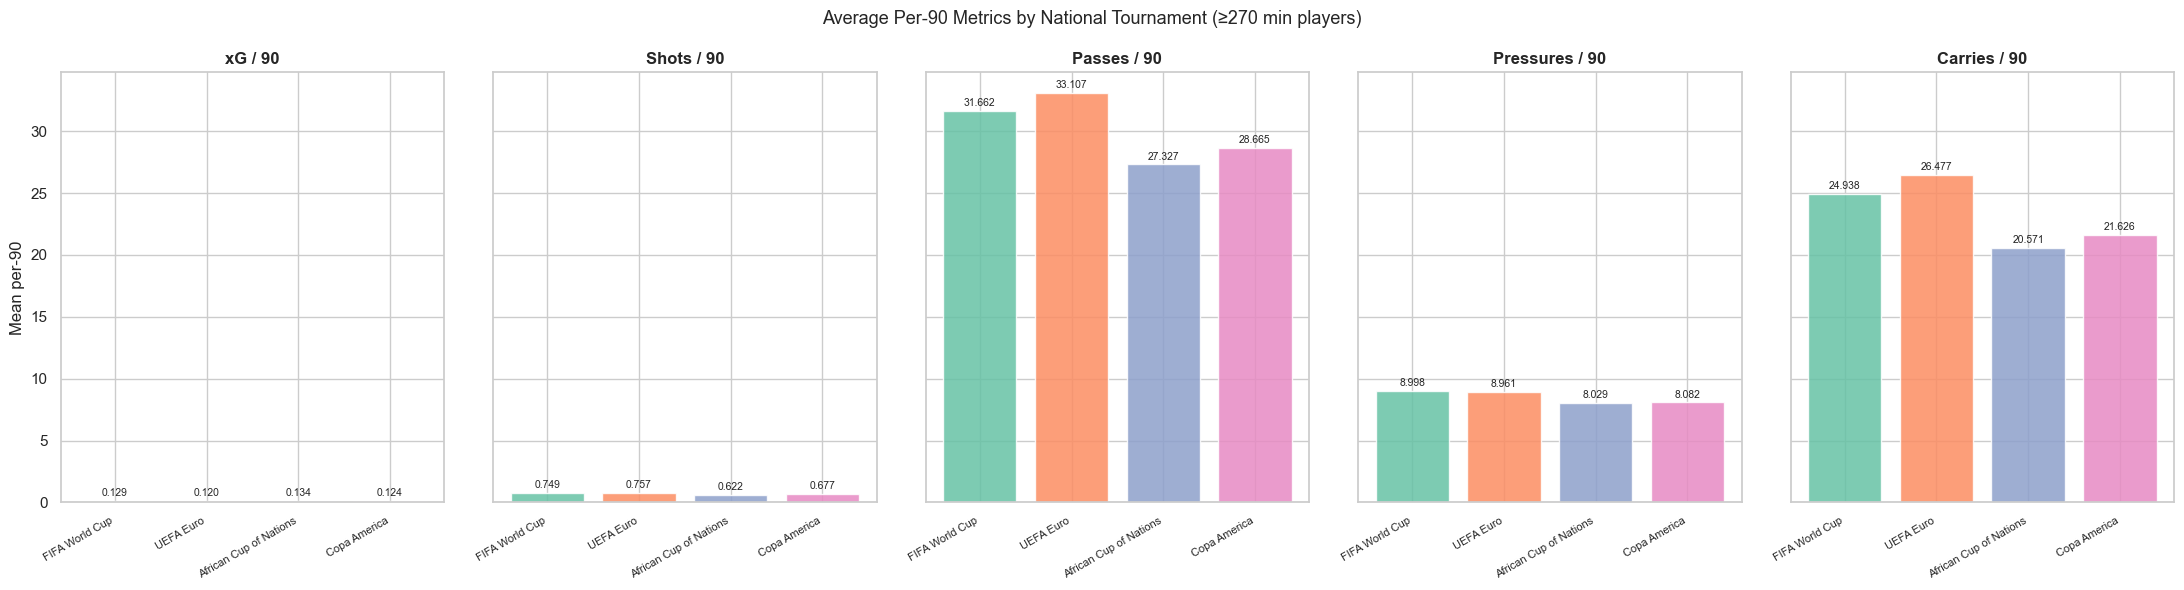

In [19]:
TOURN_METRICS = ['xg_p90', 'shots_p90', 'passes_p90', 'pressures_p90', 'carries_p90']
TOURN_LABELS  = ['xG / 90', 'Shots / 90', 'Passes / 90', 'Pressures / 90', 'Carries / 90']

# Order tournaments by total match volume
tourn_order = (
    competitions[competitions.context == 'National']
    .sort_values('matches', ascending=False)['competition_name'].tolist()
)

fig, axes = plt.subplots(1, len(TOURN_METRICS), figsize=(22, 6), sharey=True)

palette_t = sns.color_palette('Set2', len(tourn_order))

for ax, metric, label in zip(axes, TOURN_METRICS, TOURN_LABELS):
    means_t = (
        pt_eligible[pt_eligible.tournament.isin(tourn_order)]
        .groupby('tournament')[metric].mean()
        .reindex(tourn_order)
    )
    bars = ax.bar(means_t.index, means_t.values,
                  color=palette_t, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='{:.3f}', fontsize=7.5, padding=2)
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(means_t.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Mean per-90' if ax == axes[0] else '')

fig.suptitle(
    'Average Per-90 Metrics by National Tournament (≥270 min players)',
    fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_10_tournament_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Club League Comparison

Among club competitions, do average per-90 rates differ by league?
This contextualises what "club baseline" players bring to international football.

In [20]:
player_league = duck(f"""
    SELECT
        e.player, m.competition_name AS league,
        COUNT(*) FILTER (WHERE e.type = 'Shot')                            AS shots,
        SUM(e.shot_statsbomb_xg) FILTER (WHERE e.type = 'Shot')            AS xg,
        COUNT(*) FILTER (WHERE e.type = 'Pass')                            AS passes,
        COUNT(*) FILTER (WHERE e.type = 'Pass' AND e.pass_outcome IS NULL) AS passes_completed,
        COUNT(*) FILTER (WHERE e.type = 'Pressure')                        AS pressures,
        COUNT(*) FILTER (WHERE e.type = 'Carry')                           AS carries
    FROM read_parquet('{SB_EVENTS}') e
    JOIN read_parquet('{SB_MATCHES}') m ON e.match_id = m.match_id
    WHERE e.player IS NOT NULL
      AND m.gender = 'male' AND m.is_youth = false
      AND m.is_international = false
    GROUP BY e.player, m.competition_name
""")

lineup_league = duck(f"""
    SELECT l.player_name, m.competition_name AS league,
           l.from_time, l.to_time, l.match_id
    FROM read_parquet('{SB_LINEUPS}') l
    JOIN read_parquet('{SB_MATCHES}') m USING (match_id)
    WHERE l.player_name IS NOT NULL
      AND m.gender = 'male' AND m.is_youth = false
      AND m.is_international = false
""")
lineup_league['from_min'] = lineup_league['from_time'].apply(parse_time_to_minutes).fillna(0)
lineup_league['to_min']   = lineup_league['to_time'].apply(parse_time_to_minutes).fillna(90).clip(upper=120)
lineup_league['minutes_played'] = (lineup_league['to_min'] - lineup_league['from_min']).clip(lower=0)

mins_league = (
    lineup_league
    .groupby(['player_name', 'league'])
    ['minutes_played'].sum()
    .reset_index()
)

pl = player_league.merge(
    mins_league, left_on=['player', 'league'], right_on=['player_name', 'league'], how='inner'
).drop(columns='player_name')

for col in ['shots','xg','passes','passes_completed','pressures','carries']:
    pl[f'{col}_p90'] = pl[col] / pl['minutes_played'] * 90
pl['pass_completion_pct'] = pl['passes_completed'] / pl['passes'].replace(0, np.nan)

pl_elig = pl[pl['minutes_played'] >= MIN_MINUTES]

# Focus on the larger leagues
big_leagues = competitions[
    (competitions.context == 'Club') & (competitions.matches >= 50)
].sort_values('matches', ascending=False)['competition_name'].tolist()

print(pl_elig[pl_elig.league.isin(big_leagues)]
      .groupby('league')[['shots_p90','xg_p90','pressures_p90','pass_completion_pct']]
      .mean().round(3)
      .reindex(big_leagues)
      .to_string())

                     shots_p90  xg_p90  pressures_p90  pass_completion_pct
league                                                                    
La Liga                  0.720   0.094         11.815                0.742
Ligue 1                  0.797   0.096         11.290                0.761
Premier League           0.856   0.100          9.701                0.746
Serie A                  0.759   0.084          9.506                0.752
1. Bundesliga            0.873   0.108         11.164                0.734
Indian Super league      0.916   0.110          8.930                0.713


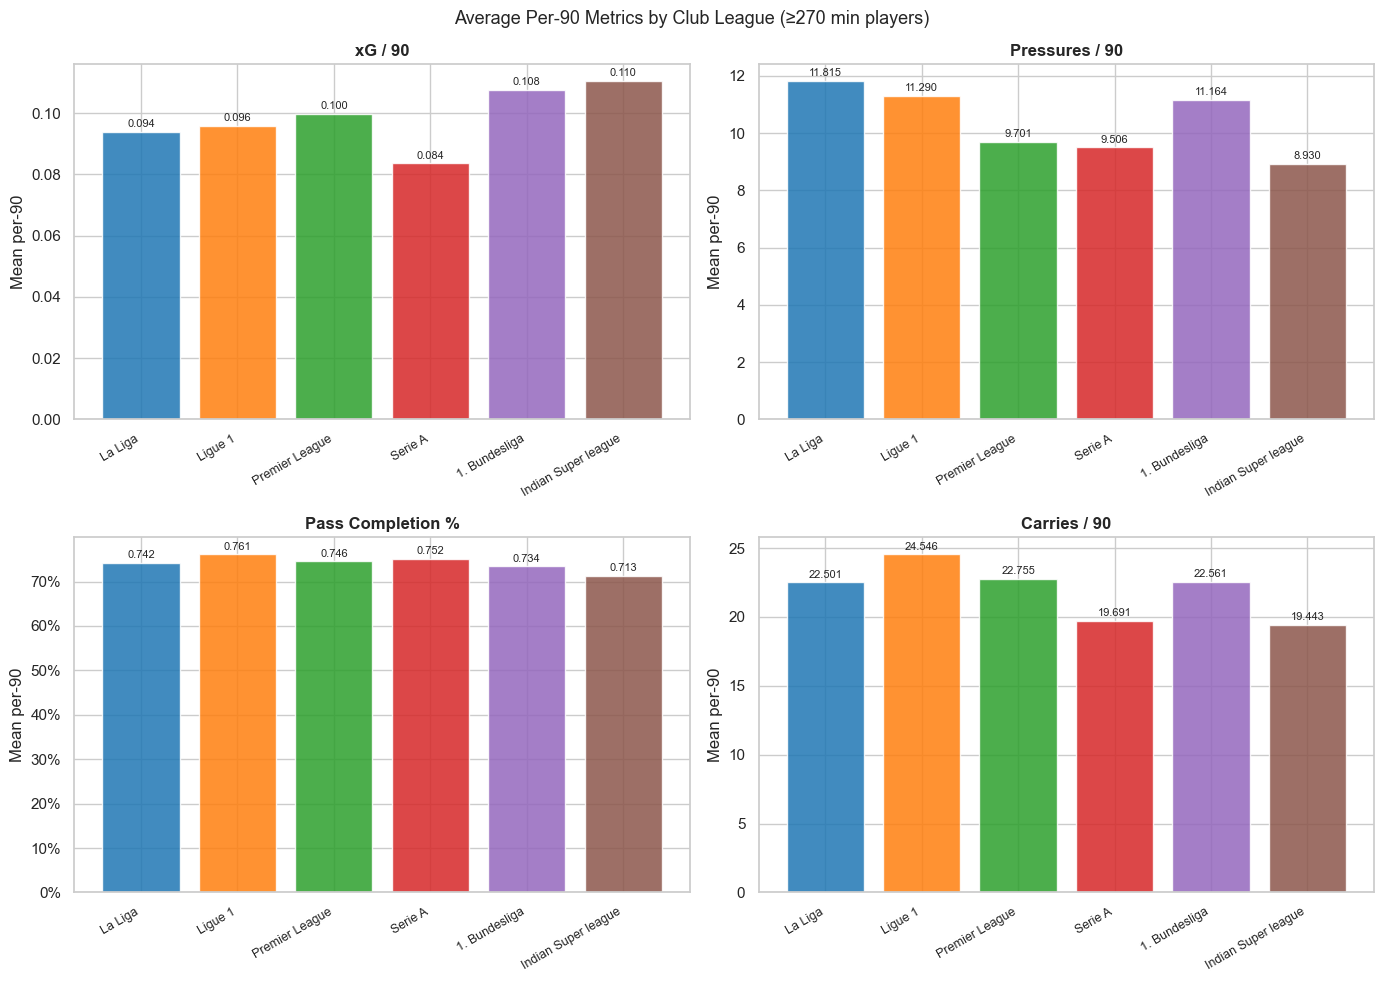

In [21]:
LEAGUE_METRICS = ['xg_p90', 'pressures_p90', 'pass_completion_pct', 'carries_p90']
LEAGUE_LABELS  = ['xG / 90', 'Pressures / 90', 'Pass Completion %', 'Carries / 90']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
palette_l = sns.color_palette('tab10', len(big_leagues))

for ax, metric, label in zip(axes, LEAGUE_METRICS, LEAGUE_LABELS):
    data = (
        pl_elig[pl_elig.league.isin(big_leagues)]
        .groupby('league')[metric].mean()
        .reindex(big_leagues)
    )
    bars = ax.bar(data.index, data.values, color=palette_l, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='{:.3f}', fontsize=8, padding=2)
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Mean per-90')
    if metric == 'pass_completion_pct':
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

fig.suptitle('Average Per-90 Metrics by Club League (≥270 min players)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_11_league_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Top Performers — Club Context

Who are the elite performers at club level for attacking and pressing metrics?
Minimum 450 minutes to qualify.

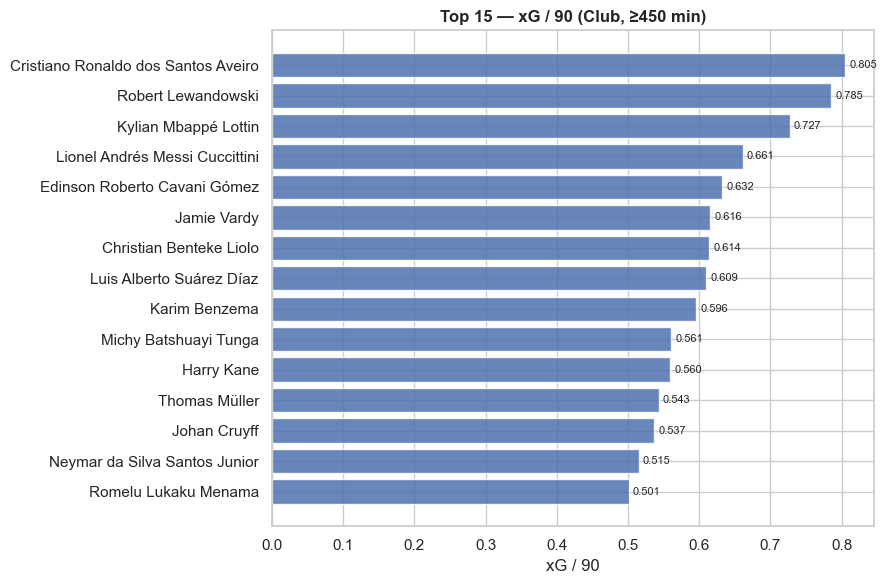

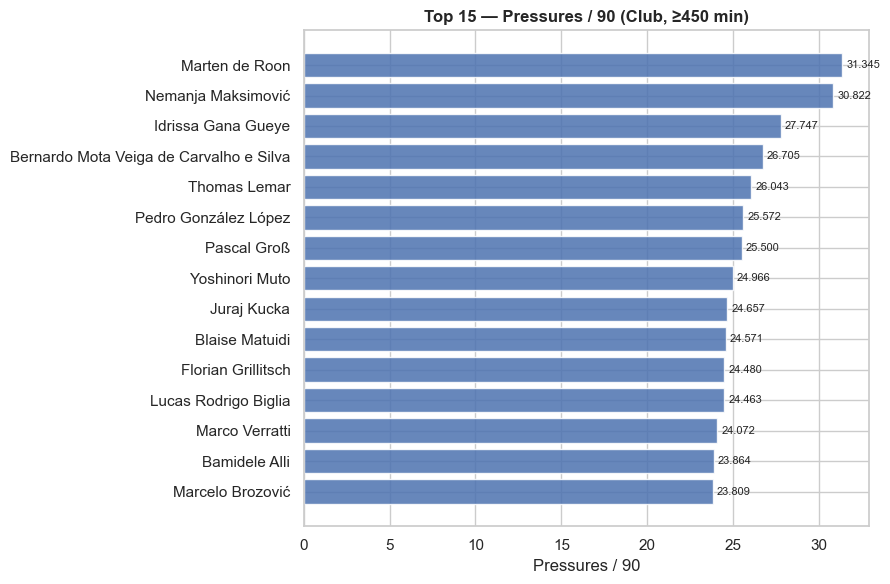

In [22]:
def top_performers_bar(df, metric_col, label, n=15, min_min=450, context_name='Club'):
    sub = df[(df['context'] == context_name) & (df['total_minutes'] >= min_min)]
    top = sub.nlargest(n, metric_col).sort_values(metric_col)
    color = CLR_CLUB if context_name == 'Club' else CLR_NATIONAL

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(top['player'], top[metric_col], color=color, alpha=0.85)
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=8)
    ax.set_xlabel(label)
    ax.set_title(f'Top {n} — {label} ({context_name}, ≥{min_min} min)',
                 fontweight='bold')
    plt.tight_layout()
    fname = os.path.join(FIGURES_DIR, f'eda_top_{context_name.lower()}_{metric_col}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

top_performers_bar(dual, 'xg_p90',        'xG / 90',         context_name='Club')
top_performers_bar(dual, 'pressures_p90', 'Pressures / 90',  context_name='Club')

---
## 15. Top Performers — National Team Context

Who stands out specifically in international football?

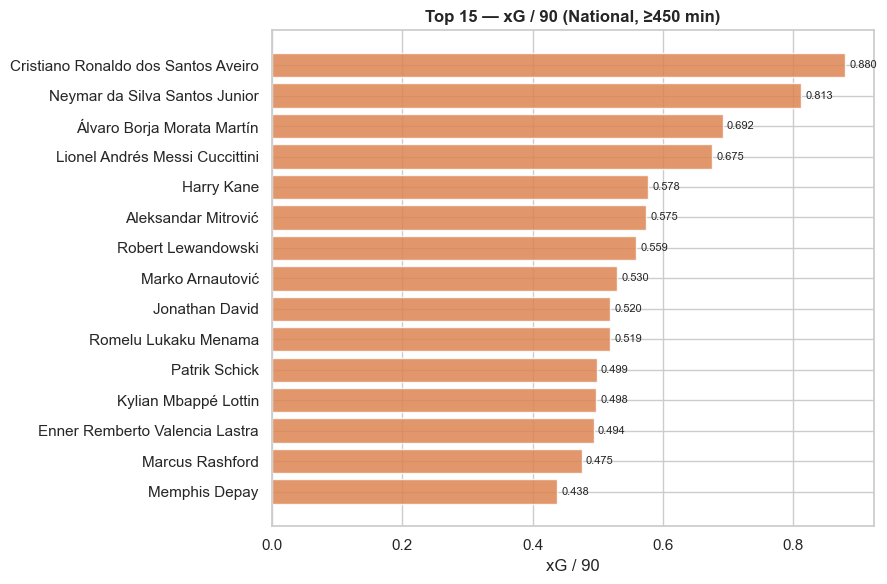

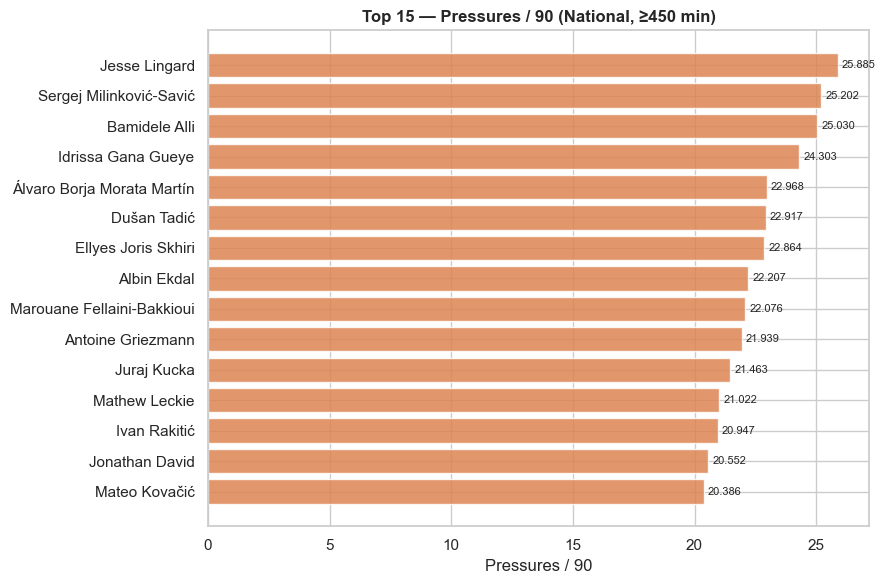

In [23]:
top_performers_bar(dual, 'xg_p90',        'xG / 90',         context_name='National')
top_performers_bar(dual, 'pressures_p90', 'Pressures / 90',  context_name='National')

---
## 16. EDA Summary

Quick recap of dataset facts and key observations from the exploration.

In [24]:
print("=" * 60)
print("EDA SUMMARY — Club vs. National Team Performance")
print("=" * 60)

club_matches_n    = int(competitions[competitions.context=='Club']['matches'].sum())
nat_matches_n     = int(competitions[competitions.context=='National']['matches'].sum())
club_comps        = competitions[competitions.context=='Club']['competition_name'].tolist()
nat_comps         = competitions[competitions.context=='National']['competition_name'].tolist()

print(f"\n  Club matches    : {club_matches_n:,} across {len(club_comps)} competitions")
print(f"  National matches: {nat_matches_n:,} across {len(nat_comps)} competitions")
print(f"  Players in BOTH contexts (any minutes): {len(both):,}")
print(f"  Players analysed (≥{MIN_MINUTES} min in both): {len(dual_players):,}")

print("\n  --- Mean per-90 by context (dual-context players) ---")
for metric, label in METRICS.items():
    c = wide[f'club_{metric}'].mean()
    n = wide[f'nat_{metric}'].mean()
    d = n - c
    direction = '▲' if d > 0 else '▼'
    print(f"  {label:30s}: Club={c:.3f}  National={n:.3f}  Δ={d:+.3f} {direction}")

print("\n  National-team competitions covered:", nat_comps)
print("="*60)

EDA SUMMARY — Club vs. National Team Performance

  Club matches    : 2,590 across 12 competitions
  National matches: 333 across 4 competitions
  Players in BOTH contexts (any minutes): 973
  Players analysed (≥270 min in both): 441

  --- Mean per-90 by context (dual-context players) ---
  xG / 90                       : Club=0.115  National=0.119  Δ=+0.004 ▲
  Shots / 90                    : Club=1.086  National=0.929  Δ=-0.158 ▼
  Passes / 90                   : Club=37.527  National=34.620  Δ=-2.907 ▼
  Pass Completion %             : Club=0.780  National=0.814  Δ=+0.034 ▲
  Att-Third Passes / 90         : Club=9.413  National=8.193  Δ=-1.220 ▼
  Pressures / 90                : Club=12.101  National=9.358  Δ=-2.744 ▼
  Carries / 90                  : Club=30.491  National=27.946  Δ=-2.544 ▼
  Duels / 90                    : Club=2.717  National=1.806  Δ=-0.911 ▼
  Dribbles / 90                 : Club=1.487  National=0.950  Δ=-0.537 ▼
  Interceptions / 90            : Club=0.847  N